# Data Exploration

## Importing libraries and dataset

In [1]:
# Importing common libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset (adjust path if necessary)
data_path = 'data/Consumer_Complaints.csv'
df = pd.read_csv(data_path, low_memory=False)
print('Loaded dataframe shape:', df.shape)
df.head(2)

Loaded dataframe shape: (903983, 18)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,3/12/2014,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,M&T BANK CORPORATION,MI,48382,NaN,NaN,Referral,3/17/2014,Closed with explanation,Yes,No,759217
1,10/1/2016,Credit reporting,NaN,Incorrect information on credit report,Account status,I have outdated information on my credit repor...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AL,352XX,NaN,Consent provided,Web,10/5/2016,Closed with explanation,Yes,No,2141773


In [3]:
df.dtypes

Date received                   object
Product                         object
Sub-product                     object
Issue                           object
Sub-issue                       object
Consumer complaint narrative    object
Company public response         object
Company                         object
State                           object
ZIP code                        object
Tags                            object
Consumer consent provided?      object
Submitted via                   object
Date sent to company            object
Company response to consumer    object
Timely response?                object
Consumer disputed?              object
Complaint ID                     int64
dtype: object

## Handling missing values

In [4]:
# checking missing values
def check_missing(dframe):
    missing = dframe.isnull().sum().sort_values(ascending=False)
    missing[missing > 0]

    missing_df = pd.DataFrame({
        'Missing Count': missing,
        'Missing %': (missing / len(df)) * 100
    }).round(2)

    return missing_df

print(check_missing(df)[check_missing(df)["Missing Count"]>0])

                              Missing Count  Missing %
Tags                                 777945      86.06
Consumer complaint narrative         704013      77.88
Company public response              646002      71.46
Consumer consent provided?           528549      58.47
Sub-issue                            477597      52.83
Sub-product                          235160      26.01
Consumer disputed?                   135408      14.98
ZIP code                               9278       1.03
State                                  9225       1.02


In [5]:
# handle "Tags" column
def encode_tags(tag):
    if pd.isna(tag) or tag.strip().lower() in ['']:
        return 4
    tag = tag.strip().lower()
    if 'older american' in tag and 'servicemember' in tag:
        return 3
    elif 'servicemember' in tag:
        return 1
    elif 'older american' in tag:
        return 2
    else:
        return 4

df['tag_class'] = df['Tags'].apply(encode_tags)
df.drop(columns=['Tags'], inplace=True)

In [6]:
df['Company public response'] = df['Company public response'].fillna('No response')

# let's assume missing values represent "N/A"
df['Consumer consent provided?'] = df['Consumer consent provided?'].fillna('N/A')

df['Sub-issue'] = df['Sub-issue'].fillna('No sub-issue')

df['Consumer complaint narrative'] = df['Consumer complaint narrative'].fillna('No customer narrative')

df['Consumer disputed?'] = df['Consumer disputed?'].fillna('No')

In [7]:
print(check_missing(df)[check_missing(df)["Missing Count"]>0])

             Missing Count  Missing %
Sub-product         235160      26.01
ZIP code              9278       1.03
State                 9225       1.02


In [8]:
# sub-product field is blank when product contains --> "credit reporting", "credit card", "payday loan"
mask_missing = df['Sub-product'].isnull()
mask_product = df['Product'].isin(['Credit reporting', 'Credit card', 'Payday loan'])

print("Missing Sub-product where Product is in target list:", df[mask_missing & mask_product].shape[0])
print("Missing Sub-product where Product is NOT in target list:", df[mask_missing & ~mask_product].shape[0])

Missing Sub-product where Product is in target list: 235160
Missing Sub-product where Product is NOT in target list: 0


In [9]:
def fill_subproduct(row):
    if pd.isna(row['Sub-product']):
        if row['Product'] == 'Credit reporting':
            return 'General credit reporting'
        elif row['Product'] == 'Credit card':
            return 'General credit card'
        elif row['Product'] == 'Payday loan':
            return 'General payday loan'
        else:
            return 'Unknown'
    return row['Sub-product']

df['Sub-product'] = df.apply(fill_subproduct, axis=1)

In [10]:
print(check_missing(df)[check_missing(df)["Missing Count"]>0])

          Missing Count  Missing %
ZIP code           9278       1.03
State              9225       1.02


In [11]:
company_zip_state_map = (
    df.dropna(subset=['Company', 'ZIP code', 'State'])
      .groupby('Company')[['ZIP code', 'State']]
      .agg(lambda x: x.mode().iloc[0])  # Most frequent ZIP and State per company
)
print(company_zip_state_map)

                                         ZIP code State
Company                                                
(Former)Shapiro, Swertfeger & Hasty, LLP    190XX    GA
1 STOP MONEY CENTERS, LLC                   85140    AZ
1ST 2ND MORTGAGE CO. OF NJ INC              074XX    NJ
1ST ALLIANCE LENDING, LLC                   95823    FL
1ST PREFERENCE MORTGAGE CORP                214XX    MD
...                                           ...   ...
iQuantified Management Services, LLC        32817    AZ
iServe Trust                                90712    CA
loanDepot.com, LLC                          300XX    CA
reekside Recovery And Capital Management    11741    CA
 Lippman Recupero, LLC                      85282    AZ

[4493 rows x 2 columns]


In [12]:
def impute_zip_state(row):
    if pd.isna(row['ZIP code']) or pd.isna(row['State']):
        company = row['Company']
        if company in company_zip_state_map.index:
            if pd.isna(row['ZIP code']):
                row['ZIP code'] = company_zip_state_map.loc[company, 'ZIP code']
            if pd.isna(row['State']):
                row['State'] = company_zip_state_map.loc[company, 'State']
    return row

df = df.apply(impute_zip_state, axis=1)

In [13]:
print(check_missing(df)[check_missing(df)["Missing Count"]>0])

          Missing Count  Missing %
ZIP code             11        0.0
State                11        0.0


In [14]:
df = df.dropna(subset=['ZIP code', 'State'])
print(check_missing(df)[check_missing(df)["Missing Count"]>0])

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


## Fixing data types

In [15]:
df['Date received'] = pd.to_datetime(df['Date received'], errors='coerce')
df['Date sent to company'] = pd.to_datetime(df['Date sent to company'], errors='coerce')

In [16]:
df['ZIP code'] = df['ZIP code'].astype(str).str.zfill(5)

In [17]:
print(check_missing(df)[check_missing(df)["Missing Count"]>0])

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


In [18]:
bool_cols = ['Timely response?', 'Consumer disputed?']
for col in bool_cols:
    df[col] = df[col].map({'Yes': True, 'No': False})

In [19]:
cat_cols = ['Product', 'Sub-product', 'Issue', 'Sub-issue', 'Company', 'State', 'Submitted via']
for col in cat_cols:
    df[col] = df[col].astype('category')

In [20]:
df['Complaint ID'] = pd.to_numeric(df['Complaint ID'], errors='coerce')

In [21]:
# show basic info and missing value counts
print(
    df.dtypes
      .to_frame(name='dtype')
      .assign(missing=df.isnull().sum()
              )
              )

                                       dtype  missing
Date received                 datetime64[ns]        0
Product                             category        0
Sub-product                         category        0
Issue                               category        0
Sub-issue                           category        0
Consumer complaint narrative          object        0
Company public response               object        0
Company                             category        0
State                               category        0
ZIP code                              object        0
Consumer consent provided?            object        0
Submitted via                       category        0
Date sent to company          datetime64[ns]        0
Company response to consumer          object        0
Timely response?                        bool        0
Consumer disputed?                      bool        0
Complaint ID                           int64        0
tag_class                   

In [22]:
print("Shape:", df.shape)
print("Unique Products:", df['Product'].nunique())
print("Unique Companies:", df['Company'].nunique())
print("Date Range:", df['Date received'].min(), "to", df['Date received'].max())

Shape: (903972, 18)
Unique Products: 18
Unique Companies: 4493
Date Range: 2011-12-01 00:00:00 to 2017-11-15 00:00:00


## Data preprocessing and checking basic info

In [23]:
# Inspect values of the response column(s) that represent outcome
for col in ['Company response to consumer', 'Timely response?', 'Consumer disputed?']:
    if col in df.columns:
        print('Unique values for', col)
        print(df[col].value_counts().head(50))
    print("----------------")

Unique values for Company response to consumer
Company response to consumer
Closed with explanation            686030
Closed with non-monetary relief    108436
Closed with monetary relief         57089
Closed without relief               17868
Closed                              17611
In progress                          7015
Closed with relief                   5304
Untimely response                    4619
Name: count, dtype: int64
----------------
Unique values for Timely response?
Timely response?
True     879368
False     24604
Name: count, dtype: int64
----------------
Unique values for Consumer disputed?
Consumer disputed?
False    755595
True     148377
Name: count, dtype: int64
----------------


In [24]:
# we will be using "company response to consumer" as the response column
resp_col = 'Company response to consumer'
df[resp_col].unique()

array(['Closed with explanation', 'Closed with monetary relief',
       'Closed without relief', 'Closed with non-monetary relief',
       'Closed with relief', 'Closed', 'Untimely response', 'In progress'],
      dtype=object)

In [25]:

upheld_vals = ['Closed with explanation', 'Closed with non-monetary relief', 
               'Closed with monetary relief', 
               'Closed with relief']
financial_vals = ['Closed with monetary relief']
if resp_col in df.columns:
    response = df[resp_col].astype(str)

    # making upheld and financial mask
    upheld_mask = response.isin(upheld_vals)
    financial_mask = response.isin(financial_vals)

    # adding upheld and financial relief columns in the dataframe
    df['upheld'] = upheld_mask
    df['financial_relief'] = financial_mask
    
    print('Derived target value counts:')
    print(df[['upheld','financial_relief']].apply(lambda s: s.value_counts()))
else:
    print(f'{resp_col} not found in dataframe')

Derived target value counts:
       upheld  financial_relief
False   47113            846883
True   856859             57089


## Visualization

### Column: 'Consumer complaint narrative'

count    903972.00000
mean        248.53910
std         627.68271
min           5.00000
25%          21.00000
50%          21.00000
75%          21.00000
max       31369.00000
Name: narrative_length, dtype: float64


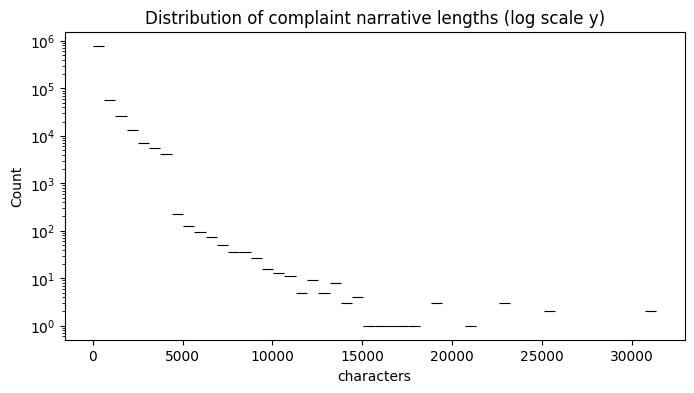

In [26]:
# Text field length distribution for 'Consumer complaint narrative'
text_col = 'Consumer complaint narrative'

df[text_col] = df[text_col].astype(str)
df['narrative_length'] = df[text_col].map(lambda x: 0 if x in ['nan'] else len(x))
print(df['narrative_length'].describe())
plt.figure(figsize=(8,4))
sns.histplot(df.loc[df['narrative_length']>0,'narrative_length'], 
                bins=50, 
                log_scale=(False, True))
plt.title('Distribution of complaint narrative lengths (log scale y)')
plt.xlabel('characters')
plt.show()

### Column: 'Product'

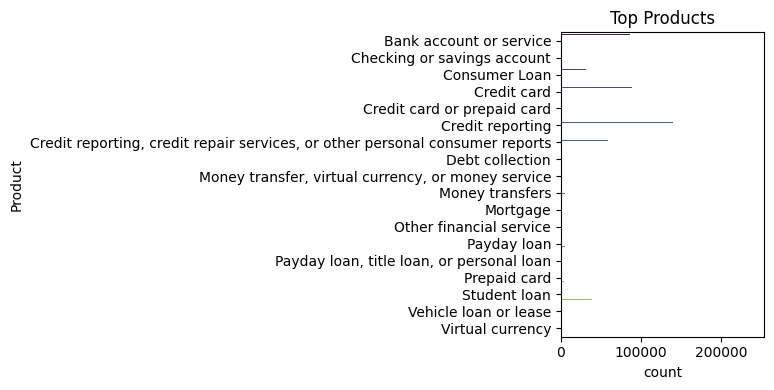

In [27]:
# Top products and top companies (counts)
for col, title in [('Product','Top Products')]:
    if col in df.columns:
        top = df[col].value_counts().head(15)
        plt.figure(figsize=(8,4))
        sns.barplot(x=top.values, y=top.index, 
                    hue=top.index, palette='viridis', legend=False)
        plt.title(title)
        plt.xlabel('count')
        plt.tight_layout()
        plt.show()

### Complaint outcome by Product type

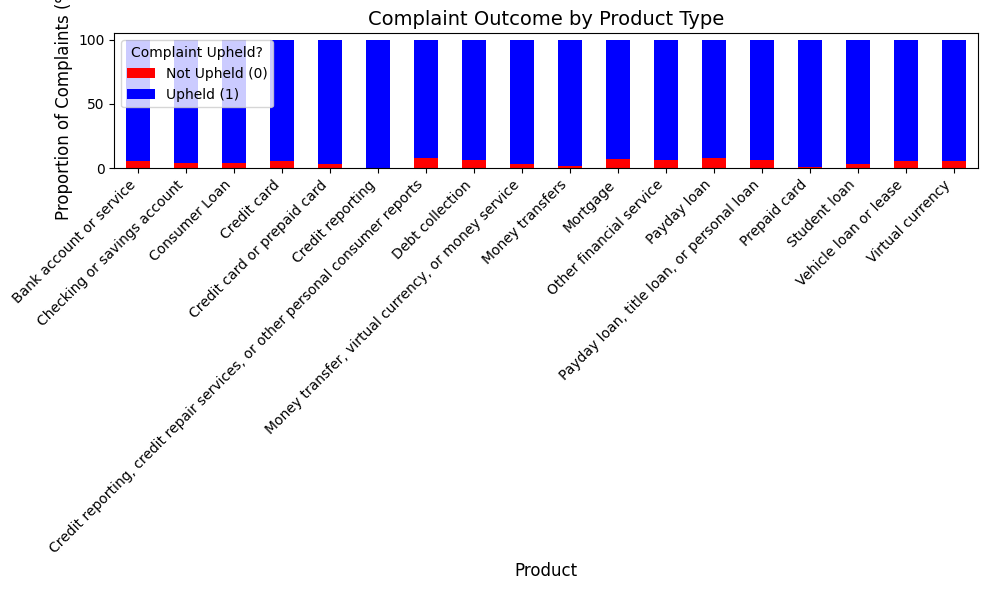

In [28]:
product_outcome = pd.crosstab(df['Product'], df['upheld'], normalize='index') * 100
product_outcome.rename(columns={False: 'Not Upheld (0)', True: 'Upheld (1)'}, inplace=True)

plt.figure(figsize=(10, 6))
product_outcome.plot(kind='bar', stacked=True, color=['red','blue'], ax=plt.gca())
plt.title('Complaint Outcome by Product Type', fontsize=14)
plt.ylabel('Proportion of Complaints (%)', fontsize=12)
plt.xlabel('Product', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Complaint Upheld?', loc='upper left')
plt.tight_layout()
plt.show()

## Target column

In [29]:
df['is_upheld'] = df['upheld'].astype(int)
df.drop(columns=['upheld'], inplace=True)

df['is_financial_relief'] = df['financial_relief'].astype(int)
df.drop(columns=['financial_relief'], inplace=True)

In [30]:
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,...,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,tag_class,narrative_length,is_upheld,is_financial_relief
0,2014-03-12,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",No sub-issue,No customer narrative,No response,M&T BANK CORPORATION,MI,48382,...,Referral,2014-03-17,Closed with explanation,True,False,759217,4,21,1,0
1,2016-10-01,Credit reporting,General credit reporting,Incorrect information on credit report,Account status,I have outdated information on my credit repor...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AL,352XX,...,Web,2016-10-05,Closed with explanation,True,False,2141773,4,200,1,0
2,2016-10-17,Consumer Loan,Vehicle loan,Managing the loan or lease,No sub-issue,I purchased a new car on XXXX XXXX. The car de...,No response,"CITIZENS FINANCIAL GROUP, INC.",PA,177XX,...,Web,2016-10-20,Closed with explanation,True,False,2163100,2,2042,1,0
3,2014-06-08,Credit card,General credit card,Bankruptcy,No sub-issue,No customer narrative,No response,AMERICAN EXPRESS COMPANY,ID,83854,...,Web,2014-06-10,Closed with explanation,True,True,885638,2,21,1,0
4,2014-09-13,Debt collection,Credit card,Communication tactics,Frequent or repeated calls,No customer narrative,No response,"CITIBANK, N.A.",VA,23233,...,Web,2014-09-13,Closed with explanation,True,True,1027760,4,21,1,0


In [31]:
df.to_pickle('cleaned_data.pkl')